# TEXT EMOTION DETECAATION

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns



### Loading the dataset

In [24]:
df = pd.read_csv("emotion_dataset.csv")

In [25]:
df.head()

,Emotion,Text
0,neutral,Why ?
1,joy,Sage Act upgrade on my to do list for tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3,joy,Such an eye ! The true hazel eye-and so brill...
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...


In [26]:
df['Emotion'].value_counts()

Emotion
joy         11045
sadness      6722
fear         5410
anger        4297
surprise     4062
neutral      2254
disgust       856
shame         146
Name: count, dtype: int64

In [28]:
# Drop rows with unwanted emotions
# remove neutral, disgust, and shame from dataset
df = df[~df['Emotion'].isin(['neutral','disgust','shame'])]

In [29]:
df['Emotion'].value_counts()

Emotion
joy         11045
sadness      6722
fear         5410
anger        4297
surprise     4062
Name: count, dtype: int64

<Axes: xlabel='Emotion', ylabel='count'>

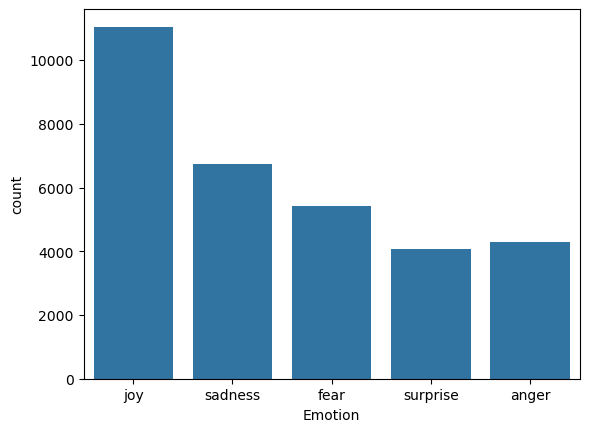

In [30]:
sns.countplot(x='Emotion',data=df)

### Data pre-processing

In [31]:
pip install neattext

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [32]:
import neattext.functions as nfx

# Remove the user handles
df['Clean_Text'] = df['Text'].apply(nfx.remove_userhandles)

In [33]:
df

,Emotion,Text,Clean_Text
1,joy,Sage Act upgrade on my to do list for tommorow.,Sage Act upgrade on my to do list for tommorow.
2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3,joy,Such an eye ! The true hazel eye-and so brill...,Such an eye ! The true hazel eye-and so brill...
4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...,ugh babe.. hugggzzz for u .! babe naamazed ...
5,fear,I'm expecting an extremely important phonecall...,I'm expecting an extremely important phonecall...
...,...,...,...
34787,surprise,@MichelGW have you gift! Hope you like it! It'...,have you gift! Hope you like it! It's hand m...
34788,joy,The world didnt give it to me..so the world MO...,The world didnt give it to me..so the world MO...
34789,anger,A man robbed me today .,A man robbed me today .
34790,fear,"Youu call it JEALOUSY, I call it of #Losing YO...","Youu call it JEALOUSY, I call it of #Losing YO..."


In [13]:
from sklearn.model_selection import train_test_split

X = df['Clean_Text']
y = df['Emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

In [34]:
import pandas as pd
from sklearn.utils import resample

train_df = pd.concat([X_train, y_train], axis=1)

min_target = train_df['Emotion'].value_counts().drop('joy').max()

balanced_train = []

for emotion, group in train_df.groupby('Emotion'):
    if emotion == 'joy':
        group = resample(
            group,
            replace=False,
            n_samples=min_target,
            random_state=42
        )
    balanced_train.append(group)

train_df = pd.concat(balanced_train).sample(frac=1, random_state=42)

X_train = train_df['Clean_Text']
y_train = train_df['Emotion']


<Axes: xlabel='Emotion'>

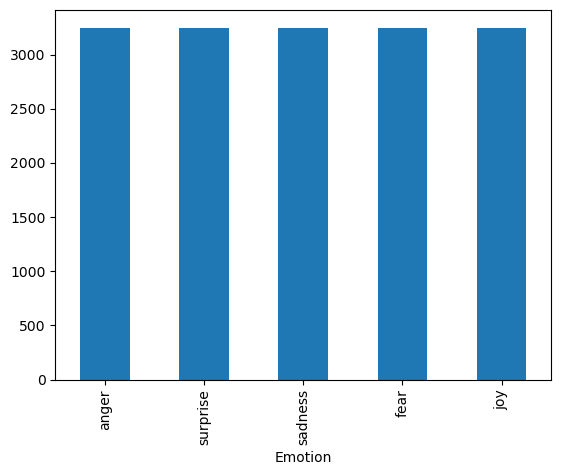

In [35]:
train_df['Emotion'].value_counts().plot(kind='bar')

In [36]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, weights))
print(class_weight)

{'anger': np.float64(1.0), 'fear': np.float64(1.0), 'joy': np.float64(1.0), 'sadness': np.float64(1.0), 'surprise': np.float64(1.0)}


In [37]:
### Training the Models

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Model 1: Logistic Regression
print("=" * 50)
print("Training Logistic Regression...")
print("=" * 50)

pipe_lr = Pipeline(steps=[
    ('cv', CountVectorizer(max_features=1000)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
pipe_lr.fit(X_train, y_train)
lr_score = pipe_lr.score(X_test, y_test)
print(f"Logistic Regression Test Accuracy: {lr_score:.4f}\n")

# Model 2: Support Vector Machine (SVM)
print("=" * 50)
print("Training SVM...")
print("=" * 50)

pipe_svm = Pipeline(steps=[
    ('cv', CountVectorizer(max_features=1000)),
    ('svc', SVC(kernel='rbf', C=10, class_weight='balanced', random_state=42))
])
pipe_svm.fit(X_train, y_train)
svm_score = pipe_svm.score(X_test, y_test)
print(f"SVM Test Accuracy: {svm_score:.4f}\n")

# Model 3: Random Forest
print("=" * 50)
print("Training Random Forest...")
print("=" * 50)

pipe_rf = Pipeline(steps=[
    ('cv', CountVectorizer(max_features=1000)),
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
rf_score = pipe_rf.score(X_test, y_test)
print(f"Random Forest Test Accuracy: {rf_score:.4f}\n")

Training Logistic Regression...
Logistic Regression Test Accuracy: 0.5560

Training SVM...
SVM Test Accuracy: 0.5577

Training Random Forest...
Random Forest Test Accuracy: 0.5693



In [38]:
### Improved Preprocessing with Lemmatization

import nltk
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Configure NLTK data path
nltk_data_dir = os.path.join(os.path.expanduser('~'), 'nltk_data')
if not os.path.exists(nltk_data_dir):
    os.makedirs(nltk_data_dir, exist_ok=True)
nltk.data.path.insert(0, nltk_data_dir)

# Download required NLTK data
print("Downloading NLTK data...")
try:
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    print("✓ NLTK data downloaded successfully\n")
except Exception as e:
    print(f"Warning: NLTK download had issues: {e}\n")

lemmatizer = WordNetLemmatizer()

def advanced_text_cleaning(text):
    """Advanced text cleaning with lemmatization"""
    try:
        # Convert to lowercase
        text = str(text).lower()
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove special characters and digits
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        
        # Tokenize
        tokens = word_tokenize(text)
        
        # Remove stopwords and lemmatize
        stop_words = set(stopwords.words('english'))
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
        
        return ' '.join(tokens)
    except Exception as e:
        # Fallback: basic cleaning without lemmatization
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        return text

# Recreate dataframe with advanced cleaning
df = pd.read_csv("emotion_dataset.csv")
df = df[~df['Emotion'].isin(['neutral','disgust','shame'])]

print("Applying advanced text cleaning...")
df['Clean_Text'] = df['Text'].apply(advanced_text_cleaning)

# Recreate train/test split
X = df['Clean_Text']
y = df['Emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# Balance training data
train_df = pd.concat([X_train, y_train], axis=1)
min_target = train_df['Emotion'].value_counts().min()

balanced_train = []
for emotion, group in train_df.groupby('Emotion'):
    balanced_group = resample(
        group,
        replace=(len(group) < min_target),
        n_samples=min_target,
        random_state=42
    )
    balanced_train.append(balanced_group)

train_df = pd.concat(balanced_train).sample(frac=1, random_state=42)
X_train = train_df['Clean_Text']
y_train = train_df['Emotion']

print(f"✓ Training set size: {len(X_train)}")
print(f"✓ Test set size: {len(X_test)}")
print(f"✓ Training data balanced:\n{y_train.value_counts()}")

✓ NLTK data downloaded successfully

Applying advanced text cleaning...
✓ Training set size: 16250
✓ Test set size: 6308
✓ Training data balanced:
Emotion
anger       3250
surprise    3250
sadness     3250
fear        3250
joy         3250
Name: count, dtype: int64


In [39]:
### Improved Models with TF-IDF and Better Parameters

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

print("\n" + "=" * 70)
print("TRAINING IMPROVED MODELS WITH TF-IDF")
print("=" * 70 + "\n")

# Model 1: Logistic Regression with L2 regularization
print("Training Logistic Regression...")
pipe_lr_v2 = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, C=0.5, random_state=42))
])
pipe_lr_v2.fit(X_train, y_train)
lr_v2_score = pipe_lr_v2.score(X_test, y_test)
print(f"✓ Accuracy: {lr_v2_score:.4f}\n")

# Model 2: SVM with Linear Kernel (faster and often better)
print("Training SVM (Linear Kernel)...")
pipe_svm_v2 = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8)),
    ('svc', SVC(kernel='linear', C=1, class_weight='balanced', random_state=42, probability=True))
])
pipe_svm_v2.fit(X_train, y_train)
svm_v2_score = pipe_svm_v2.score(X_test, y_test)
print(f"✓ Accuracy: {svm_v2_score:.4f}\n")

# Model 3: Naive Bayes (often works well with text)
print("Training Naive Bayes...")
pipe_nb = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8)),
    ('nb', MultinomialNB(alpha=0.1))
])
pipe_nb.fit(X_train, y_train)
nb_score = pipe_nb.score(X_test, y_test)
print(f"✓ Accuracy: {nb_score:.4f}\n")

# Model 4: Gradient Boosting
print("Training Gradient Boosting...")
pipe_gb = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.8)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42))
])
pipe_gb.fit(X_train, y_train)
gb_score = pipe_gb.score(X_test, y_test)
print(f"✓ Accuracy: {gb_score:.4f}\n")

print("=" * 70 + "\n")


TRAINING IMPROVED MODELS WITH TF-IDF

Training Logistic Regression...
✓ Accuracy: 0.6073

Training SVM (Linear Kernel)...
✓ Accuracy: 0.6062

Training Naive Bayes...
✓ Accuracy: 0.5915

Training Gradient Boosting...
✓ Accuracy: 0.5924




In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

print("\n" + "=" * 70)
print("TRAINING DEEP LEARNING MODEL - LSTM (FIXED VERSION)")
print("=" * 70 + "\n")

# ========================
# Tokenization
# ========================
max_words = 10000
max_len = 150

print("Tokenizing text data...")
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# ✅ مهم: نحسب الحجم الحقيقي للـ vocab
vocab_size = len(tokenizer.word_index) + 1

print(f"✓ Actual Vocabulary size: {vocab_size}")

# ========================
# Debug مهم (يتأكد مفيش error)
# ========================
max_index = max(max(seq) for seq in X_train_seq if len(seq) > 0)
print(f"✓ Max index in sequences: {max_index}\n")

# ========================
# Padding
# ========================
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f"✓ Max sequence length: {max_len}\n")

# ========================
# Label Encoding
# ========================
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(f"✓ Number of emotion classes: {len(label_encoder.classes_)}")
print(f"✓ Classes: {list(label_encoder.classes_)}\n")

# ========================
# Model
# ========================
print("Building improved LSTM model...")

model = Sequential([
    Embedding(vocab_size, 100, input_length=max_len, mask_zero=True),

    Bidirectional(LSTM(64, return_sequences=True, dropout=0.1)),
    Bidirectional(LSTM(32, dropout=0.4)),

    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),

    Dense(len(label_encoder.classes_), activation='softmax')
])
# ========================
# Compile
# ========================
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ========================
# Callbacks
# ========================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

# ========================
# Training
# ========================
print("\nTraining LSTM model...")

history = model.fit(
    X_train_pad,
    y_train_encoded,
    epochs=15,
    batch_size=500,  # 🔥 قللتها شوية لتحسين التدريب
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ========================
# Evaluation
# ========================
print("\nEvaluating on test set...")

test_loss, test_accuracy = model.evaluate(X_test_pad, y_test_encoded, verbose=0)

print(f"\n✓ LSTM Test Accuracy: {test_accuracy:.4f}")
print(f"✓ LSTM Test Loss: {test_loss:.4f}\n")
model.summary()



TRAINING DEEP LEARNING MODEL - LSTM (FIXED VERSION)

Tokenizing text data...
✓ Actual Vocabulary size: 26094
✓ Max index in sequences: 9999

✓ Max sequence length: 150

✓ Number of emotion classes: 5
✓ Classes: ['anger', 'fear', 'joy', 'sadness', 'surprise']

Building improved LSTM model...

Training LSTM model...
Epoch 1/15


C:\Users\mahmmoud\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


26/26 ━━━━━━━━━━━━━━━━━━━━ 130s 5s/step - accuracy: 0.2697 - loss: 1.5892 - val_accuracy: 0.3003 - val_loss: 1.5453 - learning_rate: 0.0010
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 121s 5s/step - accuracy: 0.3797 - loss: 1.4092 - val_accuracy: 0.4126 - val_loss: 1.3609 - learning_rate: 0.0010
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 120s 5s/step - accuracy: 0.5207 - loss: 1.1587 - val_accuracy: 0.4865 - val_loss: 1.2461 - learning_rate: 0.0010
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step - accuracy: 0.5998 - loss: 0.9940 - val_accuracy: 0.5114 - val_loss: 1.2100 - learning_rate: 0.0010
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 120s 5s/step - accuracy: 0.6565 - loss: 0.8850 - val_accuracy: 0.5428 - val_loss: 1.2529 - learning_rate: 0.0010
Epoch 6/15
17/26 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.7248 - loss: 0.7755